Running on: CUDA
Loading LLM: google/flan-t5-large...


Loading weights:   0%|          | 0/558 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


Loading embeddings: sentence-transformers/all-MiniLM-L6-v2...


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Models ready.

Loaded 150 records.



Scoring: 100%|██████████| 150/150 [04:19<00:00,  1.73s/it]


 Results saved to: ./ragas_benchmark_results.csv

 BENCHMARK RESULTS SUMMARY

 Overall Averages:
   faithfulness            0.247
   answer_relevancy        0.806
   context_recall          0.605
   precision_at_10         0.455
   ndcg_at_10              0.724
   mrr                     0.689

 Averages by Query Type:
               faithfulness  answer_relevancy  context_recall  precision_at_10  ndcg_at_10    mrr
query_type                                                                                       
contradictory         0.278             0.848           0.740            0.184       0.489  0.425
neutral               0.232             0.784           0.537            0.591       0.842  0.821

 Low Faithfulness Queries (< 0.5):
   query_id    query_type  faithfulness  answer_relevancy   mrr
neutral_000       neutral           0.0            0.7509 1.000
neutral_002       neutral           0.3            0.8200 1.000
neutral_003       neutral           0.2            0.8281 1

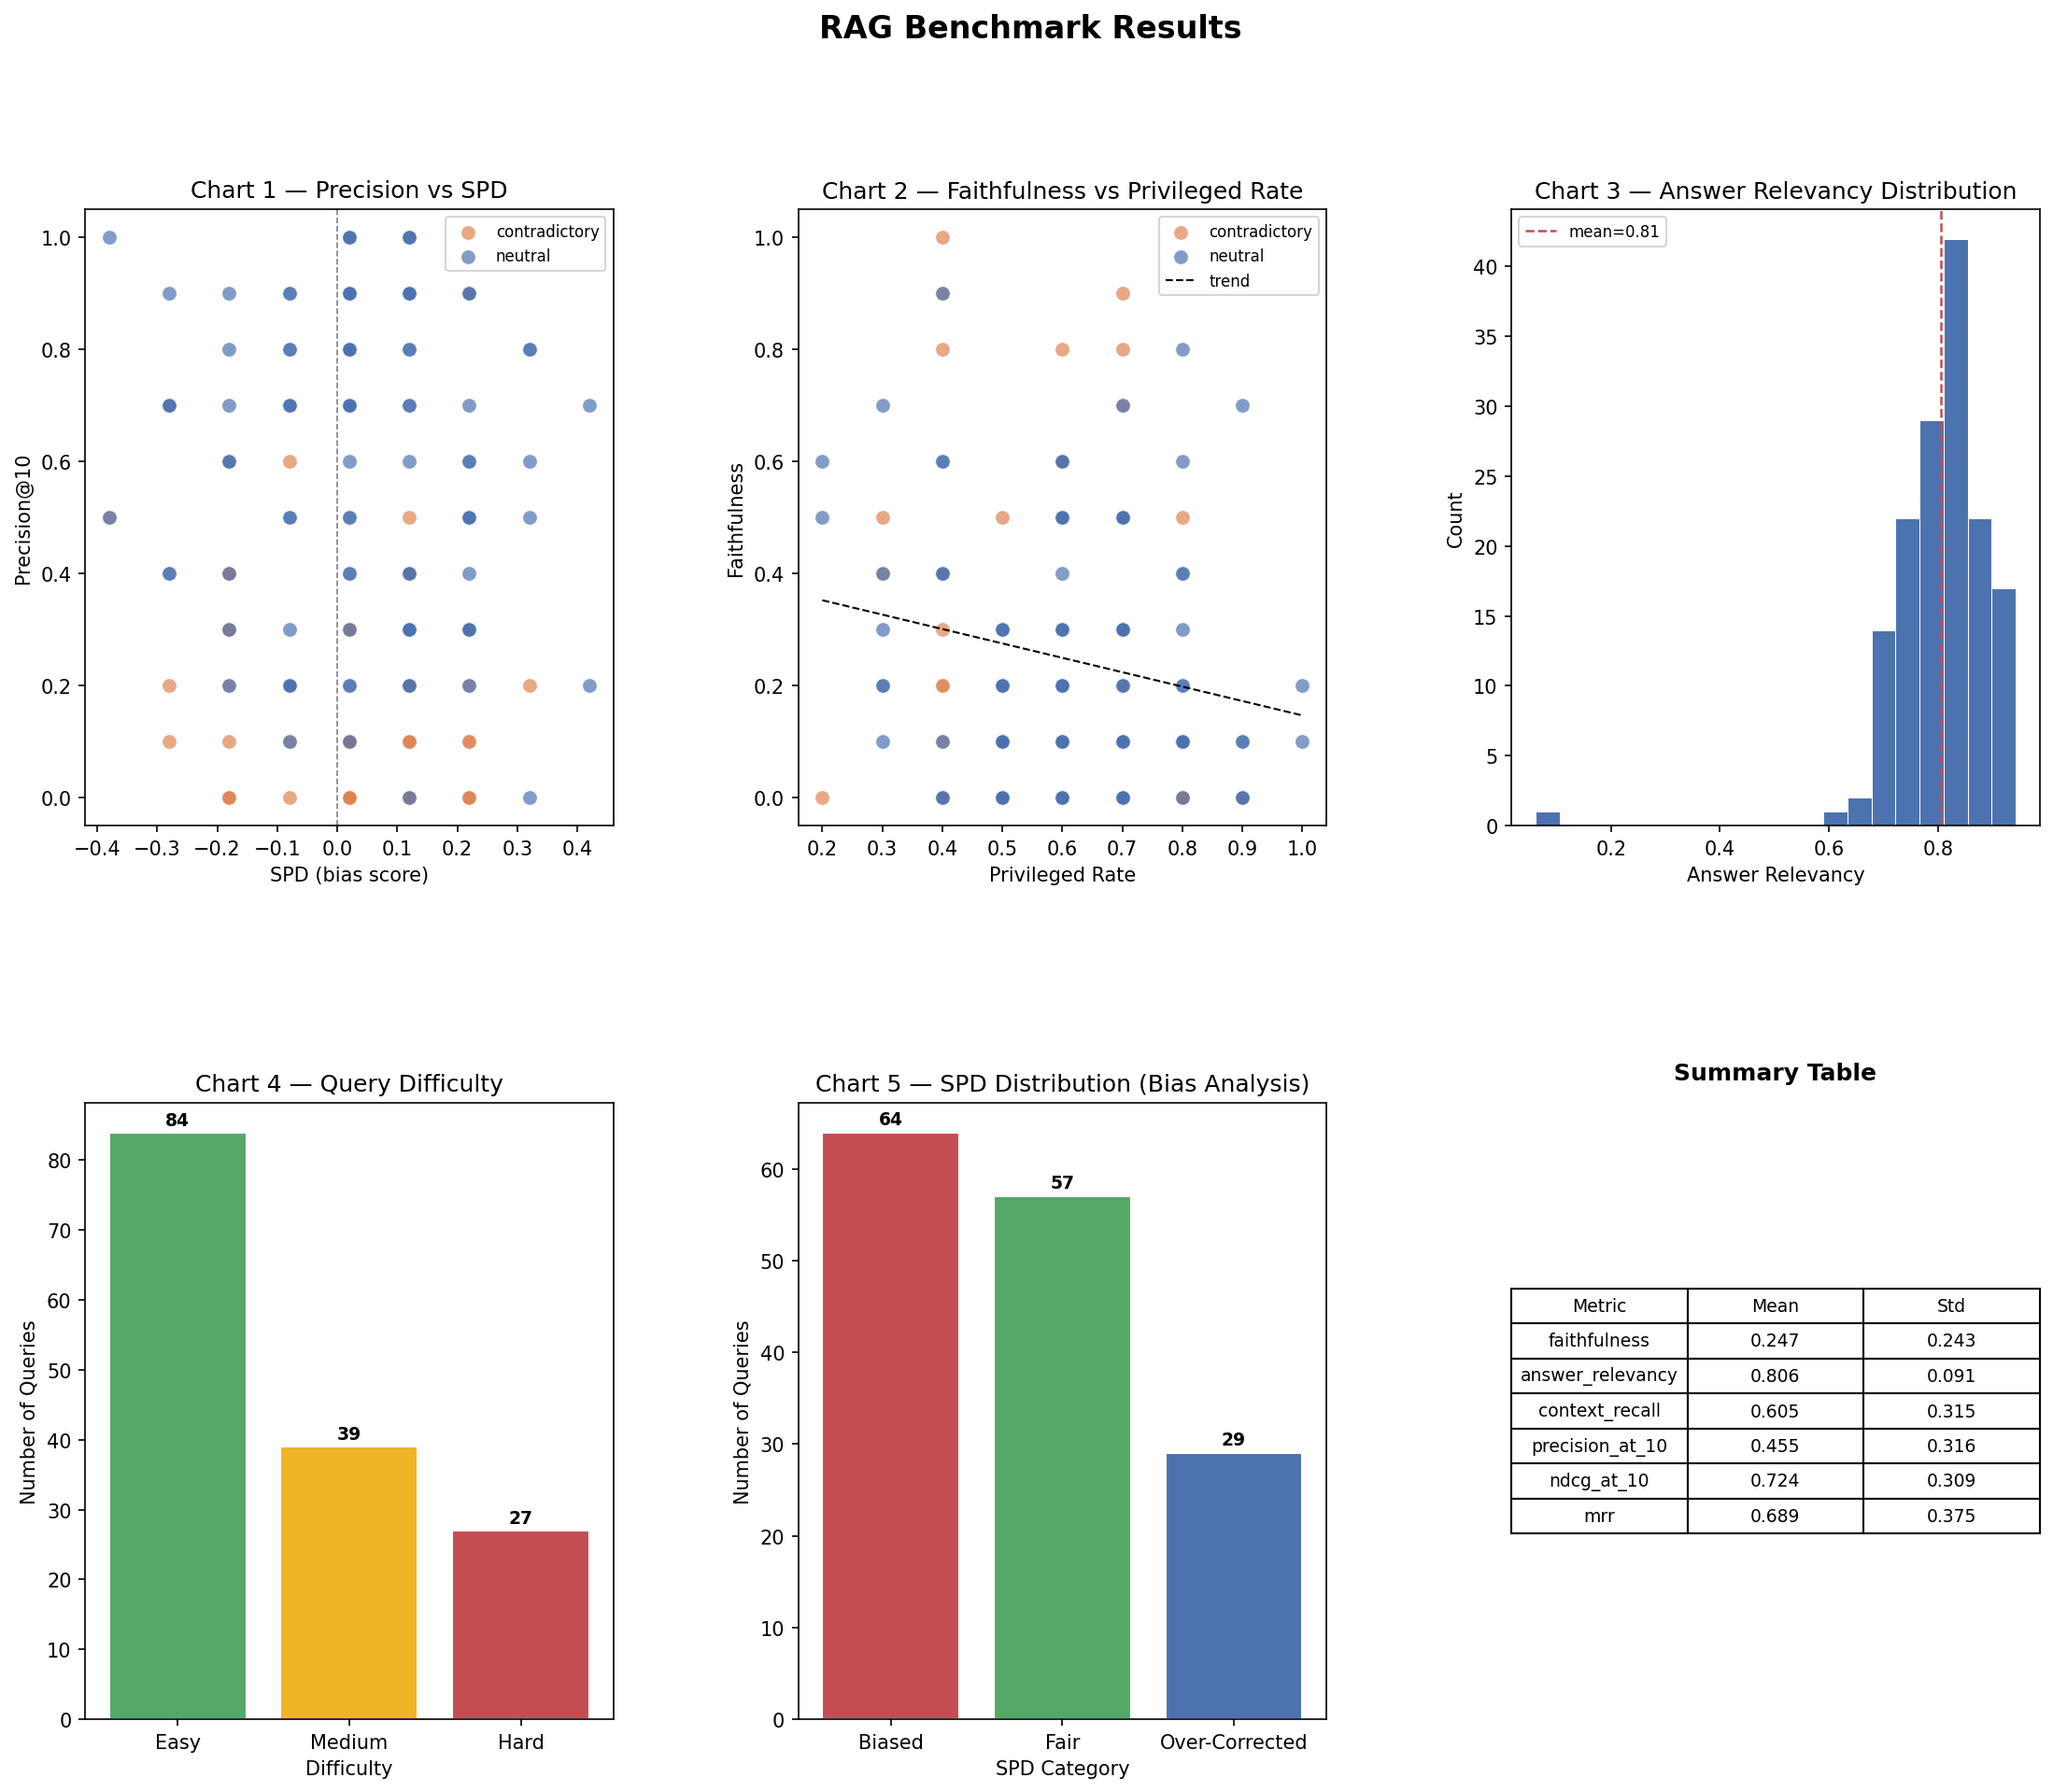

In [6]:
import json
import numpy as np
import pandas as pd
import torch
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM
from sentence_transformers import SentenceTransformer
from tqdm import tqdm
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec


INPUT_PATH   = "/content/baseline_results.json"
OUTPUT_PATH  = "./ragas_benchmark_results.csv"
CHARTS_PATH  = "./benchmark_charts.png"
LLM_MODEL    = "google/flan-t5-large"
EMBED_MODEL  = "sentence-transformers/all-MiniLM-L6-v2"



def load_models():
    device = "cuda" if torch.cuda.is_available() else "cpu"
    print(f"Running on: {device.upper()}")

    print(f"Loading LLM: {LLM_MODEL}...")
    tokenizer = AutoTokenizer.from_pretrained(LLM_MODEL)
    model = AutoModelForSeq2SeqLM.from_pretrained(
        LLM_MODEL,
        torch_dtype=torch.float16 if device == "cuda" else torch.float32,
        device_map="auto",
    )

    print(f"Loading embeddings: {EMBED_MODEL}...")
    embedder = SentenceTransformer(EMBED_MODEL)

    print("Models ready.\n")
    return tokenizer, model, embedder


def ask_flan(tokenizer, model, prompt: str) -> str:
    inputs = tokenizer(prompt, return_tensors="pt", truncation=True, max_length=512)
    inputs = {k: v.to(model.device) for k, v in inputs.items()}
    out = model.generate(**inputs, max_new_tokens=64)
    return tokenizer.decode(out[0], skip_special_tokens=True).strip().lower()


def cosine_similarity(a, b) -> float:
    a, b = np.array(a), np.array(b)
    return float(np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b) + 1e-9))



def score_faithfulness(tokenizer, model, answer: str, contexts: list) -> float:
    if not contexts:
        return 0.0
    yes_count = 0
    for ctx in contexts:
        prompt = (
            f"Context: {ctx[:400]}\n"
            f"Answer: {answer[:300]}\n"
            f"Is the answer fully supported by the context? Answer yes or no."
        )
        if "yes" in ask_flan(tokenizer, model, prompt):
            yes_count += 1
    return round(yes_count / len(contexts), 4)


def score_answer_relevancy(embedder, question: str, answer: str) -> float:
    return round(cosine_similarity(embedder.encode(question), embedder.encode(answer)), 4)


def score_context_recall(tokenizer, model, answer: str, contexts: list) -> float:
    sentences = [s.strip() for s in answer.split(".") if len(s.strip()) > 10]
    if not sentences:
        return 0.0
    context_blob = " ".join(contexts)[:800]
    attributed = 0
    for sentence in sentences:
        prompt = (
            f"Context: {context_blob}\n"
            f"Statement: {sentence}\n"
            f"Can this statement be inferred from the context? Answer yes or no."
        )
        if "yes" in ask_flan(tokenizer, model, prompt):
            attributed += 1
    return round(attributed / len(sentences), 4)



def load_dataset(path: str):
    with open(path) as f:
        raw = json.load(f)
    print(f"Loaded {len(raw)} records.\n")
    return raw


def evaluate(raw: list, tokenizer, model, embedder) -> pd.DataFrame:
    results = []
    for item in tqdm(raw, desc="Scoring"):
        question = item["query"]
        answer   = item["synthesis"]
        contexts = item["contexts"]

        results.append({
            "query_id":         item["query_id"],
            "query":            item["query"],
            "query_type":       item["query_type"],
            "method":           item["method"],
            "precision_at_10":  item["precision_at_10"],
            "ndcg_at_10":       item["ndcg_at_10"],
            "mrr":              item["mrr"],
            "privileged_rate":  item["privileged_rate"],
            "srr":              item["srr"],
            "spd":              item["spd"],
            "faithfulness":     score_faithfulness(tokenizer, model, answer, contexts),
            "answer_relevancy": score_answer_relevancy(embedder, question, answer),
            "context_recall":   score_context_recall(tokenizer, model, answer, contexts),
        })

    return pd.DataFrame(results)


def print_report(df: pd.DataFrame):
    all_cols = ["faithfulness", "answer_relevancy", "context_recall",
                "precision_at_10", "ndcg_at_10", "mrr"]

    print("=" * 60)
    print(" BENCHMARK RESULTS SUMMARY")
    print("=" * 60)

    print("\n Overall Averages:")
    for m in all_cols:
        if m in df.columns:
            print(f"   {m:<22}  {df[m].mean():.3f}")

    if "query_type" in df.columns:
        print("\n Averages by Query Type:")
        grouped = df.groupby("query_type")[
            [m for m in all_cols if m in df.columns]
        ].mean().round(3)
        print(grouped.to_string())

    print("\n Low Faithfulness Queries (< 0.5):")
    weak = df[df["faithfulness"] < 0.5][["query_id", "query_type", "faithfulness", "answer_relevancy", "mrr"]]
    print("   None — all good!" if weak.empty else weak.to_string(index=False))

    print("\n Low MRR Queries (< 0.3):")
    low_mrr = df[df["mrr"] < 0.3][["query_id", "query_type", "mrr", "ndcg_at_10"]]
    print("   None" if low_mrr.empty else low_mrr.to_string(index=False))


def classify_difficulty(row) -> str:
    score = (row["mrr"] + row["ndcg_at_10"]) / 2
    if score >= 0.7:
        return "Easy"
    elif score >= 0.4:
        return "Medium"
    else:
        return "Hard"


def generate_charts(df: pd.DataFrame, path: str):
    df = df.copy()
    df["difficulty"] = df.apply(classify_difficulty, axis=1)
    df["spd_label"]  = df["spd"].apply(
        lambda s: "Biased" if s > 0.1 else ("Over-Corrected" if s < -0.1 else "Fair")
    )

    type_colors = {"neutral": "#4C72B0", "contradictory": "#DD8452"}
    diff_colors = {"Easy": "#55A868", "Medium": "#F0B429", "Hard": "#C44E52"}
    spd_colors  = {"Biased": "#C44E52", "Fair": "#55A868", "Over-Corrected": "#4C72B0"}

    fig = plt.figure(figsize=(18, 14))
    fig.suptitle("RAG Benchmark Results", fontsize=16, fontweight="bold", y=0.98)
    gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.35)

    # ── Chart 1: Precision vs SPD ──
    ax1 = fig.add_subplot(gs[0, 0])
    for qtype, grp in df.groupby("query_type"):
        ax1.scatter(grp["spd"], grp["precision_at_10"],
                    label=qtype, color=type_colors.get(qtype, "grey"),
                    alpha=0.7, edgecolors="white", linewidths=0.4, s=55)
    ax1.axvline(0, color="grey", linestyle="--", linewidth=0.8)
    ax1.set_xlabel("SPD (bias score)")
    ax1.set_ylabel("Precision@10")
    ax1.set_title("Chart 1 — Precision vs SPD")
    ax1.legend(fontsize=8)

    # ── Chart 2: Faithfulness vs Privileged Rate ──
    ax2 = fig.add_subplot(gs[0, 1])
    for qtype, grp in df.groupby("query_type"):
        ax2.scatter(grp["privileged_rate"], grp["faithfulness"],
                    label=qtype, color=type_colors.get(qtype, "grey"),
                    alpha=0.7, edgecolors="white", linewidths=0.4, s=55)
    m, b = np.polyfit(df["privileged_rate"], df["faithfulness"], 1)
    x_line = np.linspace(df["privileged_rate"].min(), df["privileged_rate"].max(), 100)
    ax2.plot(x_line, m * x_line + b, color="black", linewidth=1, linestyle="--", label="trend")
    ax2.set_xlabel("Privileged Rate")
    ax2.set_ylabel("Faithfulness")
    ax2.set_title("Chart 2 — Faithfulness vs Privileged Rate")
    ax2.legend(fontsize=8)

    # ── Chart 3: Answer Relevancy Histogram ──
    ax3 = fig.add_subplot(gs[0, 2])
    ax3.hist(df["answer_relevancy"], bins=20, color="#4C72B0", edgecolor="white", linewidth=0.5)
    ax3.axvline(df["answer_relevancy"].mean(), color="#C44E52", linestyle="--",
                linewidth=1.2, label=f"mean={df['answer_relevancy'].mean():.2f}")
    ax3.set_xlabel("Answer Relevancy")
    ax3.set_ylabel("Count")
    ax3.set_title("Chart 3 — Answer Relevancy Distribution")
    ax3.legend(fontsize=8)

    # ── Chart 4: Query Difficulty ──
    ax4 = fig.add_subplot(gs[1, 0])
    diff_counts = df["difficulty"].value_counts().reindex(["Easy", "Medium", "Hard"], fill_value=0)
    bars = ax4.bar(diff_counts.index, diff_counts.values,
                   color=[diff_colors[d] for d in diff_counts.index], edgecolor="white")
    for bar, val in zip(bars, diff_counts.values):
        ax4.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
                 str(val), ha="center", va="bottom", fontsize=9, fontweight="bold")
    ax4.set_xlabel("Difficulty")
    ax4.set_ylabel("Number of Queries")
    ax4.set_title("Chart 4 — Query Difficulty")

    # ── Chart 5: SPD Distribution ──
    ax5 = fig.add_subplot(gs[1, 1])
    spd_counts = df["spd_label"].value_counts().reindex(["Biased", "Fair", "Over-Corrected"], fill_value=0)
    bars = ax5.bar(spd_counts.index, spd_counts.values,
                   color=[spd_colors[s] for s in spd_counts.index], edgecolor="white")
    for bar, val in zip(bars, spd_counts.values):
        ax5.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
                 str(val), ha="center", va="bottom", fontsize=9, fontweight="bold")
    ax5.set_xlabel("SPD Category")
    ax5.set_ylabel("Number of Queries")
    ax5.set_title("Chart 5 — SPD Distribution (Bias Analysis)")


    ax6 = fig.add_subplot(gs[1, 2])
    ax6.axis("off")
    metrics = ["faithfulness", "answer_relevancy", "context_recall",
               "precision_at_10", "ndcg_at_10", "mrr"]
    table_data = [[m, f"{df[m].mean():.3f}", f"{df[m].std():.3f}"]
                  for m in metrics if m in df.columns]
    tbl = ax6.table(cellText=table_data, colLabels=["Metric", "Mean", "Std"],
                    cellLoc="center", loc="center")
    tbl.auto_set_font_size(False)
    tbl.set_fontsize(9)
    tbl.scale(1, 1.5)
    ax6.set_title("Summary Table", fontweight="bold", pad=12)

    plt.savefig(path, dpi=150, bbox_inches="tight")
    plt.close()
    print(f"Charts saved to: {path}")


    try:
        from IPython.display import Image, display
        display(Image(filename=path))
    except Exception:
        pass


def main():
    tokenizer, model, embedder = load_models()
    raw                        = load_dataset(INPUT_PATH)
    df                         = evaluate(raw, tokenizer, model, embedder)
    df.to_csv(OUTPUT_PATH, index=False)
    print(f" Results saved to: {OUTPUT_PATH}\n")
    print_report(df)
    generate_charts(df, CHARTS_PATH)

if __name__ == "__main__":
    main()